# Workshop: Software tools for machine learning final project - Konrad Mocarski V13107

## Overview

This is the solution to the task given as the final project for "Workshop: Software tools for machine learning" course at the University of Milan.
The detailed task description is provided below.

## Task description
The assigned dataset has been downloaded from the [Kaggle](www.kaggle.com) and adapted for the given assignment.
A description of the corresponding features is provided [here](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction/data).
Each student is assigned a different version of the previous dataset (info on Ariel).
As a consequence, your dataset might also miss or have different features and items with respect to the one of your colleagues.

The students have to address the following points:
- [x] **_Data cleaning._** Each feature with more than 30% of empty cells has to be discarded.
In the other case, with less than 30% of empty cells, the corresponding items have to be removed from the dataset.
- [x] _**Data encoding.**_ Some of the categorical variables might be informative or not for the following steps.
As a consequence you could either decide to encode or simply to drop those features.
**Discuss your choice before finalizing the preprocessed dataset.**
- [x] Use an appropriate machine learning algorithm to infer the degree of satisfaction of the travelers (‘satisfied’ or ‘neutral or dissatisfied’).
- [x] Verify if some of the features are correlated with others.
- [x] Determine which are the **least** and the **most** relevant features with respect to the degree of satisfaction (point 2).

## Additional considerations
- Each choice and result must be explained in the notebook using as MD text.
- You are free to use any type of algorithm in the project. If you are willing to use an algorithm that has not been presented along the course,
you must explain the reason of you choice and the details of the methodology you adopted (together with online references).
- Project has to be fully documented.

### Given dataset features description

- Index: unique identifier for each passenger
- Customer Type: The customer type (Loyal customer, disloyal customer)
- Age: The actual age of the passengers
- Type of Travel: Purpose of the flight of the passengers (Personal Travel, Business Travel)
- Class: Travel class in the plane of the passengers (Business, Eco, Eco Plus)
- Flight distance: The flight distance of this journey
- Satisfaction type of features (0:Not Applicable;1-5):
    - Inflight wifi service
    - Departure/Arrival time convenient
    - Ease of Online booking
    - Gate location
    - Food and drink
    - Online boarding
    - Seat comfort
    - Inflight entertainment
    - On-board service
    - Legroom service
    - Baggage handling
    - Checkin service
    - Inflight service
    - Cleanliness
- Departure Delay in Minutes: Minutes delayed when departure
- Arrival Delay in Minutes: Minutes delayed when Arrival
- Satisfaction: Airline satisfaction level(Satisfaction, neutral or dissatisfaction)

## Remarks

Please note, that as the solution should be submitted as single .ipynb notebook file, and we don't submit the dataset file separately.
We take the assumption, that the dataset file is in the same folder as the notebook file, and it is named 'dataset_5.csv', as it's hard-coded.

## References

None for now.

In [163]:
# Imports and metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

from xgboost import XGBClassifier

data_csv = 'dataset_5.csv'
col_drop_percent = 0.3

In [164]:
# Data preparation/cleaning

df = pd.read_csv(data_csv)
col_drop_threshold = len(df) * col_drop_percent

initial_row_len = len(df)
initial_col_len = len(df.columns)
rows_dropped = 0
columns_dropped = 0

# For every column, if the amount of missing values is more than threshold, just drop it;
# Otherwise, analyze df along the column and drop each ROW from the df, when any value in the COLUMN is NULL
for col in df.columns:
    null_amount = df[col].isnull().sum()
    if null_amount > col_drop_threshold:
        print(f"Dropping column {col} with {(df[col].isnull().sum() / len(df)) * 100:.2f}% missing values")
        df.drop(col, axis=1, inplace=True)
        columns_dropped += 1
    elif null_amount > 0:
        print(f"Dropping {null_amount} rows, as feature {col} have that many NULL values")
        df.dropna(subset=[col], inplace=True)
        rows_dropped += null_amount

print(f"Amount of rows dropped: {rows_dropped}; Amount of columns dropped: {columns_dropped}")
print(f"Initial df length: {initial_row_len}; Initial df.col length: {initial_col_len}")
print(f"New df length: {len(df)}; New df.col length: {len(df.columns)}")

Dropping column Inflight entertainment with 56.48% missing values
Dropping 518 rows, as feature Arrival Delay in Minutes have that many NULL values
Amount of rows dropped: 518; Amount of columns dropped: 1
Initial df length: 3247; Initial df.col length: 24
New df length: 2729; New df.col length: 23


In [165]:
# Additional columns drop features cleaning

# Since indexing/unnamed column brings just the data ordering and
# no additional information/value for training the model, they just distort the data, we drop them.

# Rest of the data stays the same, as they might be informative, as each feature might impact the final satisfaction
# (ex. Business class/Loyal customers might have bigger expectations than the others regarding different features, we want to analyze it);
# (or another ex. older people might care less about the wifi connection on board if they don't use it much -- we analyze the feature correlation further).

# We additionally drop Customer Type data, as it is not a feature that we want to analyze,
# as it is not directly related to the satisfaction, but rather to the loyalty of the customer,
# which is a different aspect of the customer experience.

df.drop(columns=['index', 'Unnamed: 0', 'Customer Type'], inplace=True)
print(f"New df length: {len(df)}; New df.col length: {len(df.columns)}")
df.info()

New df length: 2729; New df.col length: 20
<class 'pandas.core.frame.DataFrame'>
Index: 2729 entries, 0 to 3246
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                2729 non-null   int64  
 1   Type of Travel                     2729 non-null   object 
 2   Class                              2729 non-null   object 
 3   Flight Distance                    2729 non-null   int64  
 4   Inflight wifi service              2729 non-null   int64  
 5   Departure/Arrival time convenient  2729 non-null   int64  
 6   Ease of Online booking             2729 non-null   int64  
 7   Gate location                      2729 non-null   int64  
 8   Food and drink                     2729 non-null   int64  
 9   Online boarding                    2729 non-null   int64  
 10  Seat comfort                       2729 non-null   int64  
 11  On-board service  

In [166]:
# Data encoding

# For further model train/test, we encode textual features into numerical ones.
# If the data is already in numerical value, we leave it as is, as it provides enough information on its own.

# Binary features -- just 0 for less important class/values, 1 for potential bigger expectations.
# Same for satisfaction measure, 0 for neutral/dissatisfied and 1 for satisfied.
df['Type of Travel'] = df['Type of Travel'].map({'Personal travel': 0, 'Personal Travel': 0, 'Business travel': 1, 'Business Travel': 1})
df['satisfaction'] = df['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

# Ordinal features -- there exists clear hierarchy between the classes, so we can encode them with increasing integers.
df['Class'] = df['Class'].map({'Eco': 0, 'Eco Plus': 1, 'Business': 2})

df.head()

,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,63,1,2,1014,1,1,1,1,3,5,4,5,5,5,5,5,3,21,23.0,1
1,38,1,2,1705,4,4,2,4,1,1,1,5,5,5,1,5,4,0,0.0,1
2,25,1,2,406,1,5,1,1,1,0,1,5,4,5,3,4,1,1,0.0,0
3,46,0,0,964,2,4,2,1,1,4,1,3,2,4,3,4,1,0,0.0,0
6,57,1,2,2227,2,2,1,2,4,3,4,4,4,5,4,3,4,184,167.0,1


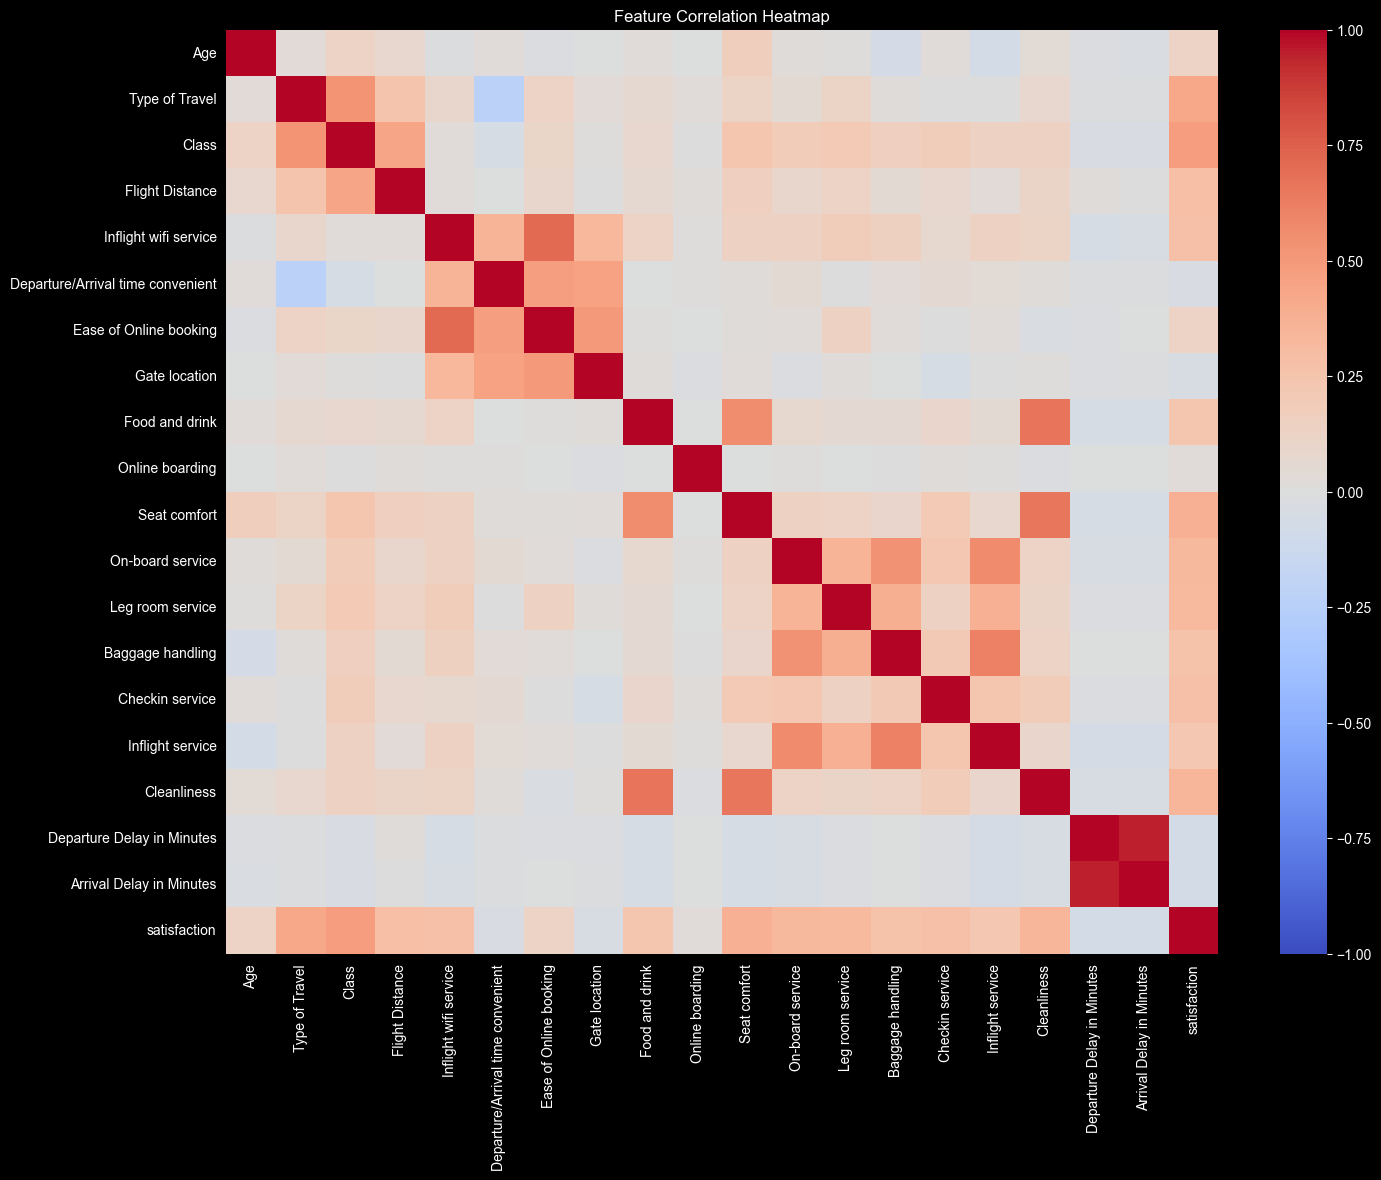

In [167]:
# Feature correlation analysis

# We are looking for very dark red (positive correlation; as one increases, so does the other)
# or dark blue (negative correlation; as one increases, the other decreases) squares off the main diagonal.

correlation_matrix = df.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)

plt.title('Feature Correlation Heatmap')
plt.show()

In [168]:
# For better data analysis and learning outcome, we discard one of two features that are highly correlated with some other one.
# It might create Multicollinearity, which occurs in regression analysis when two or more independent variables are highly correlated,
# meaning one can be linearly predicted from the others with high accuracy.
# Multicollinearity violates the assumption of independence among predictors, making it difficult to isolate individual effects.

# In case of above analysis, we get rid of any one of the two features, that has correlation on the threshold being >0.85.

# Implementation very similar/same to the one on Lesson 8 with feat selection.ipynb
def drop_highly_correlated_features(df_init, threshold=0.85):
    corr_matrix = np.abs(df_init.corr())

    upper_triangle_mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    upper_triangle = corr_matrix.where(upper_triangle_mask)

    cols_to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] >= threshold)]
    df_reduced = df_init.drop(columns=cols_to_drop)

    return df_reduced, cols_to_drop

df, dropped_cols = drop_highly_correlated_features(df)
print(f"Dropped columns: {dropped_cols} due to highly correlation with some other columns")

Dropped columns: ['Arrival Delay in Minutes'] due to highly correlation with some other columns


In [169]:
# Infer the degree of satisfaction of the travelers

# Since we are predicting a binary outcome (satisfaction), we treat this task as the Classification task.
# As we are dealing with some 'surveys data', we will use a XGBClassifier algorithm, that uses the collection
# of decision trees to classify data into different classes. It works very similarly to Random Forest Classifier, but additionally recognizes,
# when the number in the array is NaN and then sends that passenger down the left branch and right branch of the decision tree to later permanently adapt
# whichever direction yields the highest accuracy. It's cool as it doesn't require feature scaling and captures complex, non-linear relationships.
# We want to classify, based on some measure of satisfaction of each of the features, whether the customer, based on fed data,
# ended up being happy or not. Training the model revolves around the model being able to answer the question for ex.
# "If customer rated some list of features as X, will he come out satisfied or not?"

# Separate the features (X) and the target variable (y)
X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

# We replace each 0 from the survey data with a NaN to not treat 0 (not-applicable) worse than grade 1 on the scale 1-5 (where 1 is the worst experience).
# Notice that we don't change any other zeros in the dataset (Class, Delay, Type of Travel, etc.).
survey_columns = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]
X[survey_columns] = X[survey_columns].replace(0, np.nan)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# n_estimators=100 means it will build 100 sequential boosting rounds (trees).
# eval_metric='logloss' is explicitly set to avoid warnings in newer XGBoost versions.
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

print("--- Model Evaluation ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Neutral/Dissatisfied (0)', 'Satisfied (1)']))

--- Model Evaluation ---
Overall Accuracy: 93.53%

Classification Report:
                          precision    recall  f1-score   support

Neutral/Dissatisfied (0)       0.95      0.93      0.94       456
           Satisfied (1)       0.92      0.94      0.93       363

                accuracy                           0.94       819
               macro avg       0.93      0.94      0.93       819
            weighted avg       0.94      0.94      0.94       819



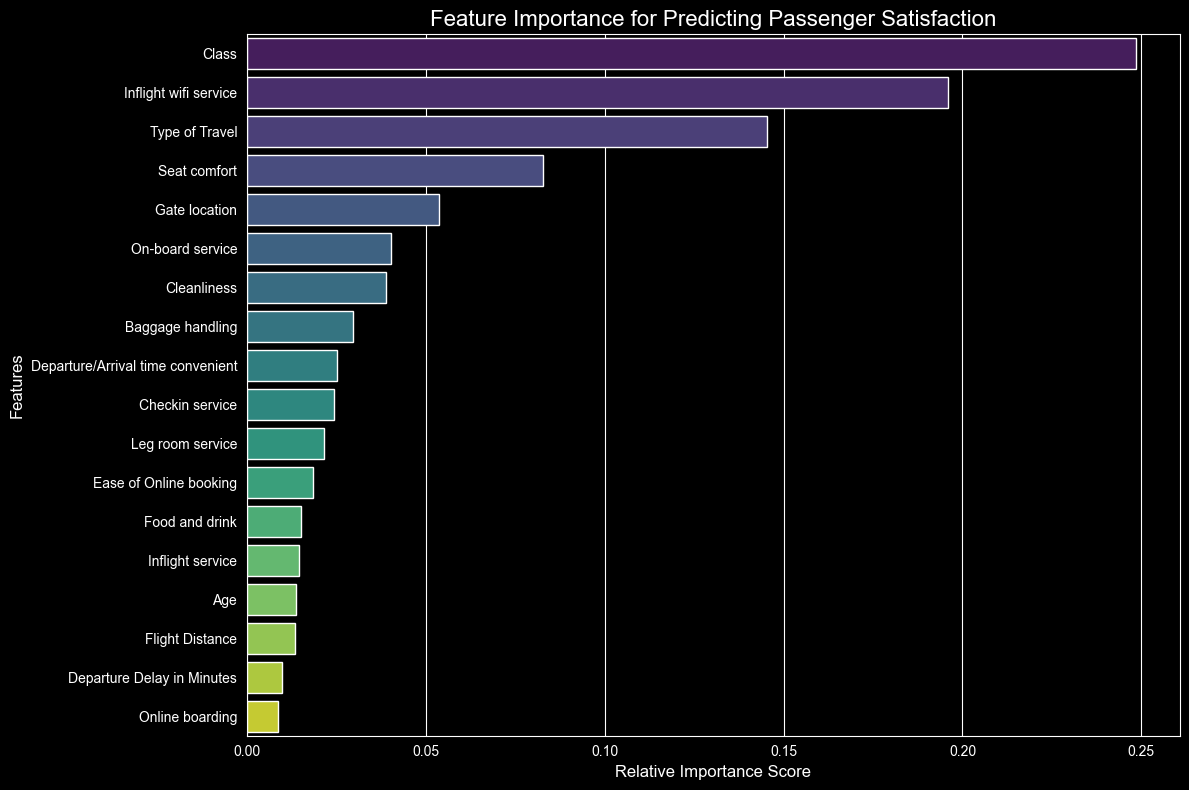

In [170]:
# Determine which are the least and the most relevant features with respect to the degree of satisfaction

# After training the model, we use XGBClassifier Feature Visualisation to determine which of the features were
# the most impactful, while predicting the satisfaction, and which were the least impactful.
# This will be based on the feature importance scores, which are calculated based on how much each feature contributes
# to the reduction of impurity in the decision trees of the forest of decision trees.

# Read the feature importance and sort the values from highest to lowest.
importances = pd.DataFrame({'Feature': X.columns,'Importance': xgb_model.feature_importances_})
importances = importances.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# print("--- TOP 5 MOST RELEVANT FEATURES ---")
# print(importances.head(5))
#
# print("\n--- TOP 5 LEAST RELEVANT FEATURES ---")
# print(importances.tail(5).iloc[::-1])

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')

plt.title('Feature Importance for Predicting Passenger Satisfaction', fontsize=16)
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()